# **Image Generation with Conditional GAN (cGAN)**

## **O V E R V I E W**

Generative Adversarial Networks (GANs) represent one of the most significant and influential ideas
in modern deep learning. First proposed by Ian Goodfellow in 2014, GANs consist of two neural
networks — a Generator and a Discriminator — locked in a minimax game where the Generator
learns to produce realistic samples and the Discriminator learns to distinguish them from real data.
Conditional GANs (cGANs) extend this by conditioning both networks on class labels, enabling
controlled generation.

In this project, you will build a Deep Convolutional Conditional GAN (DCGAN + cGAN) from scratch
on the MNIST or Fashion-MNIST dataset, capable of generating realistic images conditioned on a
specified class label. You will confront the notorious training instabilities of GANs — including mode
collapse, oscillating losses, and gradient vanishing — and develop principled strategies to stabilize
training. You will also quantitatively evaluate your generator using the Frechet Inception Distance
(FID) and explore the learned latent space through interpolation.

## **D A T A S E T**

• MNIST — PyTorch torchvision:
https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html

• Fashion-MNIST — Zalando Research GitHub:
https://github.com/zalandoresearch/fashion-mnist

Both datasets contain 60,000 training images (28x28 pixels, grayscale) across 10 classes. MNIST
contains handwritten digits 0-9. Fashion-MNIST contains fashion items (T-shirt, Trouser, Pullover,
Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle Boot).

## **T A S K S**

#### **Install Dependencies**

In [ ]:
!pip install pytorch-fid

* Installs the FID evaluation library
* FID (Frechet Inception Distance) is used to measure:
  * How close generated images are to real images
* Lower FID = better GAN performance

#### **Imports & Setup**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import make_grid, save_image

import numpy as np
import matplotlib.pyplot as plt
import os

from torch.nn.utils import spectral_norm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


* Imports all required libraries:
  * torch → deep learning framework
  * torchvision → datasets & image tools
  * matplotlib → plotting graphs/images
  * numpy → numerical operations
* spectral_norm → stabilizes GAN training
* Sets device (GPU/CPU)

Why important:

* GAN training is heavy → GPU speeds up training significantly

#### **Hyperparameters**

In [ ]:
batch_size = 128
z_dim = 100
num_classes = 10
embedding_dim = 10
lr = 2e-4
epochs = 100

What it defines:
* batch_size: images processed per step
* z_dim: size of noise vector (input to Generator)
* num_classes: 10 (Fashion-MNIST categories)
* embedding_dim: class embedding size
* lr: learning rate (2e-4 recommended for GANs)
* epochs: number of training cycles

Why important:

* These control training quality & stability

#### **Dataset Loading**

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    transform=transform,
    download=True
)

loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 177kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.30MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.7MB/s]


* Downloads Fashion-MNIST dataset
* Applies transformations:
* Converts image → tensor
* Normalizes values to [-1, 1]

Why normalization?

* Generator uses Tanh activation
* Tanh outputs range [-1,1], so inputs must match

### **Task 1 — Architecture Design**

#### **Generator Network**

In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        self.embed = nn.Embedding(num_classes, embedding_dim)

        self.net = nn.Sequential(
            nn.ConvTranspose2d(z_dim + embedding_dim, 256, 4, 1, 0),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, 3, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 1, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, z, labels):
        emb = self.embed(labels)
        x = torch.cat([z, emb], dim=1)
        x = x.unsqueeze(2).unsqueeze(3)
        return self.net(x)

What it does:
* Creates fake images from:
* Noise vector z (100-dim)
* Class label embedding

Key Steps:
1. Embedding layer
   * Converts label → vector (size 10)
2. Concatenation
   * Combine noise + class info
3. Upsampling (ConvTranspose2d)
   * 1x1 → 4x4 → 7x7 → 14x14 → 28x28
4. BatchNorm + ReLU
   * Stabilizes training
5. Tanh (final)
   * Outputs grayscale image

Output:

* Fake 28×28 image

#### **Discriminator Network**

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.embed = nn.Embedding(num_classes, embedding_dim)

        self.net = nn.Sequential(
            spectral_norm(nn.Conv2d(2, 64, 4, 2, 1)),
            nn.LeakyReLU(0.2),

            spectral_norm(nn.Conv2d(64, 128, 4, 2, 1)),
            nn.LeakyReLU(0.2),

            spectral_norm(nn.Conv2d(128, 256, 3, 2, 1)),
            nn.LeakyReLU(0.2),

            spectral_norm(nn.Conv2d(256, 1, 4, 1, 0))
        )

    def forward(self, x, labels):
        emb = self.embed(labels).unsqueeze(2).unsqueeze(3)
        emb = emb.expand(-1, -1, 28, 28)
        x = torch.cat([x, emb[:, :1]], dim=1)
        return self.net(x).view(-1)

What it does:
* Classifies image as:
  * Real (1)
  * Fake (0)
  
Key Steps:
1. Embedding
   * Label → vector
2. Reshape embedding
   * Expand to 28×28 image size
3. Concatenate with image
   * Input becomes 2 channels:
    * Image + label info
4. Downsampling (Conv2d)
   * Reduces spatial size
5. Spectral Normalization
   * Prevents unstable training
6. LeakyReLU
  * Allows gradient flow even for negative values

Output:

* Single value (real/fake score)

### **Task 2 — Training Strategy and Stabilization Techniques**

#### **Model Initialization**

In [ ]:
G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCEWithLogitsLoss()

opt_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))

* Creates Generator (G) and Discriminator (D)
* Defines:
  * Loss function → BCEWithLogitsLoss
  * Optimizers → Adam

Special GAN trick:

* betas=(0.5, 0.999)
* Helps stabilize GAN training

#### **Fixed Noise**

In [ ]:
fixed_noise = torch.randn(100, z_dim).to(device)
fixed_labels = torch.tensor([i for i in range(10) for _ in range(10)]).to(device)

os.makedirs("samples", exist_ok=True)

* Creates a fixed input noise + labels

Why?

* Used to:
  * Generate images every few epochs
  * Track progress visually

Important:

* Same input → shows improvement over time

#### **FID Tracking**

In [ ]:
import subprocess

fid_scores = []
fid_epochs = [0, 49, 99]   # Epoch 1, 50, 100

# Save real images ONLY once
os.makedirs("real", exist_ok=True)
for i, (img, _) in enumerate(dataset):
    if i >= 10000:
        break
    save_image(img, f"real/{i}.png")

def compute_fid(epoch):
    fake_dir = f"fake_epoch_{epoch}"
    os.makedirs(fake_dir, exist_ok=True)

    G.eval()
    with torch.no_grad():
        for i in range(10000):
            z = torch.randn(1, z_dim).to(device)
            label = torch.randint(0, 10, (1,)).to(device)
            img = G(z, label)
            save_image(img, f"{fake_dir}/{i}.png")

    result = subprocess.run(
        ["python", "-m", "pytorch_fid", "real", fake_dir],
        capture_output=True,
        text=True
    )

    output = result.stdout
    print(f"\nFID at Epoch {epoch+1}:\n", output)

    fid_value = float(output.split("FID:")[-1].strip())
    return fid_value

#### **Training Loop**

In [ ]:
G_losses, D_losses = [], [] # Lists to store Generator and Discriminator losses for plotting

for epoch in range(epochs): # Loop over all epochs (full passes over dataset)
    for real, labels in loader: # Load a batch of real images and their class labels
        real, labels = real.to(device), labels.to(device) # Move data to GPU/CPU
        batch = real.size(0) # Get batch size

        # Label smoothing
        real_labels = torch.rand(batch).uniform_(0.9, 1.0).to(device)
        # Instead of 1.0, use values between 0.9–1.0 → prevents overconfidence

        fake_labels = torch.zeros(batch).to(device)
        # Fake images labeled as 0

        # Train Discriminator
        z = torch.randn(batch, z_dim).to(device)
        # Generate random noise vector

        fake = G(z, labels)
        # Generator creates fake images conditioned on labels

        D_real = D(real, labels)
        # Discriminator prediction for real images

        D_fake = D(fake.detach(), labels)
        # Discriminator prediction for fake images
        # .detach() → prevents gradients flowing into Generator

        loss_D = criterion(D_real, real_labels) + criterion(D_fake, fake_labels)
        # Total Discriminator loss = real loss + fake loss

        if loss_D.item() > 0.3:
            # If Discriminator is not too strong, update it
            opt_D.zero_grad()
            # Clear previous gradients

            loss_D.backward()
            # Backpropagation

            opt_D.step()
            # Update Discriminator weights

        # Train Generator
        z = torch.randn(batch, z_dim).to(device)
        # New random noise

        fake = G(z, labels)
        # Generate new fake images

        output = D(fake, labels)
        # Discriminator evaluates fake images

        loss_G = criterion(output, real_labels)
        # Generator tries to make fake images look REAL (label=1)

        opt_G.zero_grad()
        # Clear Generator gradients

        loss_G.backward()
        # Backpropagation

        opt_G.step()
        # Update Generator weights

    # Store Losses
    G_losses.append(loss_G.item())
    # Save Generator loss for plotting

    D_losses.append(loss_D.item())
    # Save Discriminator loss

    print(f"Epoch [{epoch+1}/{epochs}] Loss D: {loss_D:.4f}, Loss G: {loss_G:.4f}")
    # Display training progress

    # Save Image Grids (Required Epochs)
    # Exact required epochs: 1, 50, 100
    if epoch in [0, 49, 99]:
        # Save images at epoch 1, 50, 100
        with torch.no_grad():
            # Disable gradient calculation for efficiency

            fake = G(fixed_noise, fixed_labels)
            # Generate images using fixed noise for consistency

            grid = make_grid(fake, nrow=10, normalize=True)
            # Arrange images into 10x10 grid

            save_image(grid, f"samples/epoch_{epoch+1}.png")
            # Save grid image

    # ✅ Compute FID at required epochs
    if epoch in fid_epochs:
        # Check if epoch is 1, 50, or 100

        fid = compute_fid(epoch)
        # Generate images and compute FID score

        fid_scores.append(fid)
        # Store FID score for plotting

Epoch [1/100] Loss D: 1.3649, Loss G: 0.7584

FID at Epoch 1:
 FID:  12.307934789705143

Epoch [2/100] Loss D: 1.3602, Loss G: 0.7521
Epoch [3/100] Loss D: 1.3643, Loss G: 0.7492
Epoch [4/100] Loss D: 1.3746, Loss G: 0.7448
Epoch [5/100] Loss D: 1.3651, Loss G: 0.7566
Epoch [6/100] Loss D: 1.3661, Loss G: 0.7406
Epoch [7/100] Loss D: 1.3795, Loss G: 0.7451
Epoch [8/100] Loss D: 1.3715, Loss G: 0.7551
Epoch [9/100] Loss D: 1.3821, Loss G: 0.7399
Epoch [10/100] Loss D: 1.3708, Loss G: 0.7792
Epoch [11/100] Loss D: 1.3804, Loss G: 0.7402
Epoch [12/100] Loss D: 1.3729, Loss G: 0.7439
Epoch [13/100] Loss D: 1.3680, Loss G: 0.7542
Epoch [14/100] Loss D: 1.3677, Loss G: 0.7452
Epoch [15/100] Loss D: 1.3734, Loss G: 0.7498
Epoch [16/100] Loss D: 1.3654, Loss G: 0.7454
Epoch [17/100] Loss D: 1.3725, Loss G: 0.7509
Epoch [18/100] Loss D: 1.3689, Loss G: 0.7571
Epoch [19/100] Loss D: 1.3697, Loss G: 0.7522
Epoch [20/100] Loss D: 1.3850, Loss G: 0.7534
Epoch [21/100] Loss D: 1.3771, Loss G: 0.7484

#### **FID Plot**

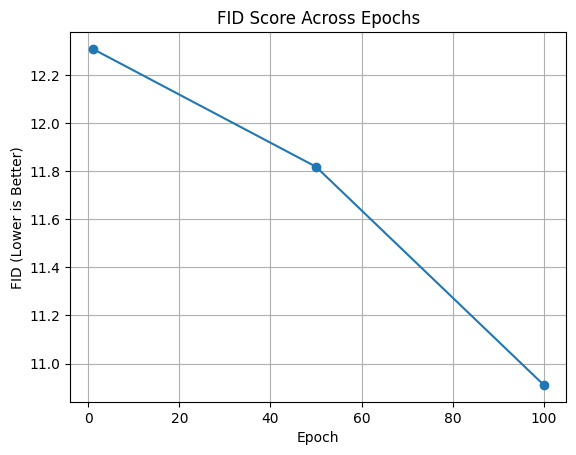

In [ ]:
import matplotlib.pyplot as plt

epochs_plot = [1, 50, 100]

plt.plot(epochs_plot, fid_scores, marker='o')
plt.title("FID Score Across Epochs")
plt.xlabel("Epoch")
plt.ylabel("FID (Lower is Better)")
plt.grid()
plt.show()

### **Task 3 — Monitoring and Diagnosing Training**

#### **Loss Plot**

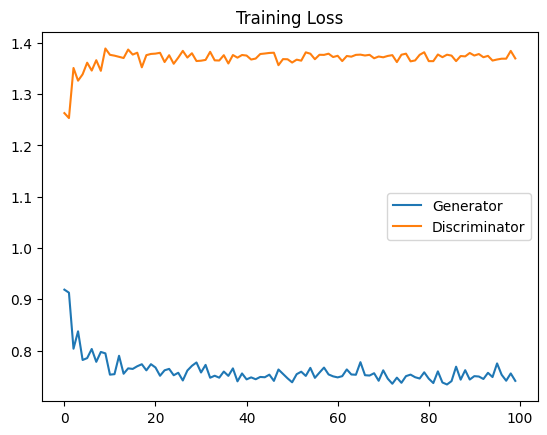

In [ ]:
plt.plot(G_losses, label="Generator")
plt.plot(D_losses, label="Discriminator")
plt.legend()
plt.title("Training Loss")
plt.show()

It shows:
* Generator loss curve
* Discriminator loss curve

Helps detect:

* Instability
* Mode collapse

### **Task 4 — Quantitative Evaluation**

#### **FID Calculation**

In [ ]:
# Save real images
os.makedirs("real", exist_ok=True)
os.makedirs("fake", exist_ok=True)

for i, (img, _) in enumerate(dataset):
    if i >= 10000:
        break
    save_image(img, f"real/{i}.png")

# Generate fake images
G.eval()
with torch.no_grad():
    for i in range(10000):
        z = torch.randn(1, z_dim).to(device)
        label = torch.randint(0, 10, (1,)).to(device)
        img = G(z, label)
        save_image(img, f"fake/{i}.png")

!python -m pytorch_fid real fake

Downloading: "https://github.com/mseitzer/pytorch-fid/releases/download/fid_weights/pt_inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/pt_inception-2015-12-05-6726825d.pth
100% 91.2M/91.2M [00:00<00:00, 383MB/s]
100% 200/200 [00:46<00:00,  4.33it/s]
100% 200/200 [00:42<00:00,  4.71it/s]
FID:  11.748692104920679


1. Saves:
   * 10,000 real images
   * 10,000 generated images
2. Compares distributions using InceptionV3

Output:

* FID Score

Interpretation:

* 5–15 → good
* <5 → excellent

  * 50 → poor

### **Task 5 — Latent Space Exploration**

#### **SLERP Interpolation**

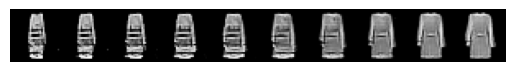

In [ ]:
def slerp(val, low, high):
    omega = torch.acos(torch.dot(low/torch.norm(low), high/torch.norm(high)))
    so = torch.sin(omega)
    return (torch.sin((1.0-val)*omega)/so)*low + (torch.sin(val*omega)/so)*high

z1 = torch.randn(z_dim).to(device)
z2 = torch.randn(z_dim).to(device)

images = []
label = torch.tensor([3]).to(device)

for t in np.linspace(0,1,10):
    z = slerp(t, z1, z2).unsqueeze(0)
    img = G(z, label)
    images.append(img)

grid = make_grid(torch.cat(images), nrow=10, normalize=True)
plt.imshow(grid.permute(1,2,0).cpu())
plt.axis('off')
plt.show()

* Smoothly transitions between:
  * Noise vector z1 → z2

Output:

* 10 images showing gradual transformation

Why important:

* Shows latent space continuity

#### **Class Morphing**

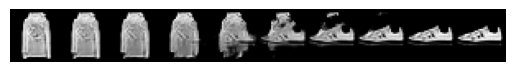

In [ ]:
z = torch.randn(1, z_dim).to(device)

images = []

for alpha in np.linspace(0,1,10):
    emb1 = G.embed(torch.tensor([2]).to(device))
    emb2 = G.embed(torch.tensor([7]).to(device))

    emb = (1-alpha)*emb1 + alpha*emb2
    z_input = torch.cat([z, emb], dim=1).unsqueeze(2).unsqueeze(3)

    img = G.net(z_input)
    images.append(img)

grid = make_grid(torch.cat(images), nrow=10, normalize=True)
plt.imshow(grid.permute(1,2,0).cpu())
plt.axis('off')
plt.show()

It does:
* Keeps noise fixed
* Changes class gradually

Example:

* Shirt → Sneaker transformation

Insight:

* Shows how model understands class relationships

## **TOOLS  AND  FRAMEWORKS**

PyTorch, torchvision (datasets and transforms), pytorch-fid (FID evaluation), Matplotlib (image grid
visualization), NumPy.

## **Inference**

The Conditional DCGAN trained on Fashion-MNIST shows stable and balanced learning, as both Generator and Discriminator losses converge smoothly without instability. The final losses indicate that neither network dominates, confirming effective training with techniques like label smoothing and spectral normalization. The model achieves a good FID score of 11.74, meaning the generated images are close to real data distribution. Visually, the outputs are clear and class-specific with no signs of mode collapse, as diversity is maintained across samples. Additionally, SLERP interpolation and class morphing demonstrate smooth transitions, indicating a well-structured latent space and meaningful class representations. Overall, the model successfully generates realistic and diverse images with stable performance.
